# Notebook 12 – Feature Relationships

## Correlation Matrix

A Correlation Matrix shows the relationship between multiple numerical variables

The most common correlation measure is Pearson correlation

The correlation coefficient ranges from:

           −1 ≤ r ≤ 1

### Interpretation:

Correlation  	Meaning

 +1	          Perfect positive relationship
 +0.7	      Strong positive relationship
 +0.5	      Moderate positive relationship
  0	          No linear relationship
 -0.5	      Moderate negative relationship
 -0.7	      Strong negative relationship
 -1	          Perfect negative relationship

 Example:

Suppose:

Study Hours ↑
Exam Score ↑

If:

correlation = +0.85

there is a strong positive linear relationship.

If:

correlation = -0.80

when one variable increases, the other tends to decrease.

Important: Correlation does not prove causation.

### Business Example:

A company may check:

Age
Experience
Salary
Working Hours
Performance Score

If:

Experience ↔ Salary = 0.90

then experience and salary have a strong positive relationship

In [1]:
import pandas as pd                             #PythonExample
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    "Age": [20, 22, 25, 28, 30],
    "Experience": [1, 2, 4, 6, 8],
    "Salary": [25000, 28000, 35000, 45000, 55000]
}

df = pd.DataFrame(data)

correlation_matrix = df.corr()

print(correlation_matrix)

                 Age  Experience    Salary
Age         1.000000    0.995191  0.982728
Experience  0.995191    1.000000  0.995415
Salary      0.982728    0.995415  1.000000


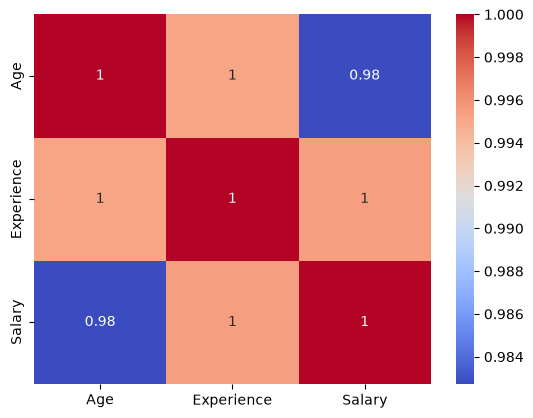

In [2]:
sns.heatmap(                         #Heatmap
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.show()

## Multicollinearity

Multicollinearity occurs when two or more independent features in a dataset are highly related to each other

For example:

House Size
House Area in Sq. Feet
Number of Rooms

Some of these variables may contain very similar information.

Example:

X1 = Experience
X2 = Years_Worked

If:

Correlation(X1, X2) = 0.95
there may be multicollinearity.

Why is Multicollinearity a Problem?

Suppose we build:

Salary = β0 + β1(Experience) + β2(Years_Worked)

If Experience and Years_Worked contain almost the same information, the model may struggle to determine how much contribution comes from each feature.

This can cause:

Unstable coefficients
Difficult interpretation
Large standard errors
Less reliable statistical inference
Sometimes reduced model stability

For some prediction models, multicollinearity is less problematic than for linear-model coefficient interpretation, especially with regularization

### Assumptions:

Multicollinearity is mainly about relationships among predictor variables.

Check:

Correlation between numerical features
VIF values
Dummy-variable encoding issues
Features that are mathematical combinations of other features
When to Check

Check multicollinearity when:

Building Linear Regression.
Building Logistic Regression.
You need interpretable coefficients.
Many predictors seem to contain duplicate information.

### Business Example:

Suppose a bank has:

Annual Income
Monthly Income
Annual Bonus
Total Compensation

Annual Income and Monthly Income may be strongly related.

Keeping all of them can create unnecessary redundancy

## Variance Inflation Factor (VIF)

VIF — Variance Inflation Factor measures how much the variance of an estimated regression coefficient is inflated because of relationships between predictor variables

It is commonly used to detect multicollinearity.

Formula:

For feature \(X_j\):

$$ VIF_j = \frac{1}{1-R_j^2} $$

Where:

R
j
2
	​

 = R-squared obtained by predicting feature \(X_j\) using the other predictor features

### Interpretation

A common practical guideline is:

VIF	    Interpretation

1	   No multicollinearity

1–5	   Usually acceptable

5–10	Potentially high

>10	   Often considered serious

These are rules of thumb, not universal law

In [3]:
import pandas as pd                                                       #PythonExample
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = pd.DataFrame({
    "Age": [20, 22, 25, 28, 30, 32],
    "Experience": [1, 2, 4, 6, 8, 10],
    "Salary": [25000, 28000, 35000, 45000, 55000, 65000]
})

vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)       

      Feature          VIF
0         Age   353.266161
1  Experience  1915.294330
2      Salary   699.061033


In [ ]:
Here:

Experience VIF = 1915.2944330

This suggests strong multicollinearity involving Experience

What can we do?

We could investigate whether:

Experience

is redundant with another predictor.

Possible solutions:

Remove one of the highly redundant features.
Combine related features.
Use regularization such as Ridge/Lasso.
Use dimensionality reduction such as PCA when appropriate

## Feature Importance


Feature Importance tells us how useful each feature is for making predictions in a machine-learning model

For example, suppose we predict customer churn:

Age
Income
Monthly Charges
Contract Type
Tenure

The model may tell us:

Tenure          → 35%
Monthly Charges → 30%
Contract Type   → 20%
Income          → 10%
Age              → 5%

This tells us which features contributed more to the model's predictions

Feature importance is model-dependent.

Different models can produce different importance measures.

Common approaches include:

1.Tree-based importance

Used by:

Decision Tree
Random Forest
Gradient Boosting

2.Permutation Importance

Randomly shuffles a feature and observes how much model performance decreases.

3.SHAP

SHAP values explain how individual features contribute to predictions

### Interpretation:

Suppose we get:

Feature       Importance
Salary           0.50
Experience       0.35
Age              0.15

The model found Salary more useful than Age for its predictions


In [12]:
from sklearn.ensemble import RandomForestClassifier               #PythonExample
from sklearn.model_selection import train_test_split

X = df[["Age", "Experience", "Salary"]]

# Example target
y = [0, 0, 0, 1, 1]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print(importance.sort_values(
    "Importance",
    ascending=False
))

      Feature  Importance
1  Experience    0.382022
0         Age    0.337079
2      Salary    0.280899


# Feature Selection Basics

Feature Selection means selecting the most useful features for a machine-learning model and removing unnecessary or redundant features

Suppose we have:

100 Features
      ↓
Feature Selection
      ↓
20 Useful Features

Why Feature Selection?

Feature selection can help:

Reduce model complexity
Reduce training time
Reduce noise
Improve interpretability
Reduce overfitting in some situations
Make models easier to maintain

Types of Feature Selection:

There are three major approaches:

Feature Selection
      |
      ├── Filter Methods
      |
      ├── Wrapper Methods
      |
      └── Embedded Methods

### A. Filter Methods

Features are selected using statistical properties before training the model.

Examples:

Correlation
Chi-Square
ANOVA
Mutual Information
Variance Threshold
Example

If:

Feature A ↔ Target = 0.85
Feature B ↔ Target = 0.02

Feature A may be more useful than Feature B, depending on the problem

### 2.Wrapper Methods

Wrapper methods select features by repeatedly training a model using different feature subsets.

One popular method is:

RFE — Recursive Feature Elimination
All Features
     ↓
Train Model
     ↓
Remove Least Useful Feature
     ↓
Train Again
     ↓
Repeat

Interpretation

support_ = True

means the feature was selected.

support_ = False

means the feature was not selected


### 3. Embedded Methods

Feature selection happens during model training.

Examples:

Lasso Regression
Decision Trees
Random Forest
Gradient Boosting
Lasso Example

Lasso uses L1 regularization.

Some coefficients can become exactly zero:

Feature A → 0.85
Feature B → 0.32
Feature C → 0
Feature D → 0.14

Feature C may effectively be removed by the model.

In [13]:
from sklearn.feature_selection import VarianceThreshold     #PythonExampleforFiltermethods

selector = VarianceThreshold(threshold=0.01)

X_selected = selector.fit_transform(X)

print(X_selected.shape)

(5, 3)


In [14]:
from sklearn.feature_selection import RFE                   #PythonExampleforWrapperModels
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

rfe = RFE(
    estimator=model,
    n_features_to_select=2
)

rfe.fit(X, y)

print(rfe.support_)
print(rfe.ranking_)

[ True False  True]
[1 2 1]
